In [ ]:
import warnings
warnings.filterwarnings("ignore")

#### Using Pydantic Class ---> Structuring the LLM Output

- Pydantic automatically validates the data, ensuring that it conforms to the expected types and constraints.

- The key advantage of using Pydantic is that the model-generated output will be validated. Pydantic will raise an error if any required fields are missing or if any fields are of the wrong type.

**Summary :** By using a Pydantic class, you're essentially telling the LLM: 
- **"Hey, whatever output you generate, make sure it conforms to the structure and format I’ve defined in this Pydantic class."**

#### Key Takeaway
- The LLM generates data, but Pydantic ensures it’s **filtered** and **reshaped** to match your requirements.
- This process effectively transforms raw, unstructured data into something clean, usable, and reliable.

#### Why is this Useful?

1. **Validation**:  
   Pydantic automatically validates the data. If the LLM or any other system gives invalid data, Pydantic will raise clear errors.

2. **Formatting**:  
   Pydantic ensures the output is in a specific format. This is especially useful when working with APIs or structured data from LLMs.

3. **Error Prevention**:  
   By catching issues early, you avoid bugs in later parts of your program.


##### 📊 Side-by-side summary: TypedDict vs Pydantic

| Creation style      | TypedDict | Pydantic |
|--------------------|-----------|----------|
| Constructor (`Class(...)`) | `dict` | Model object |
| `Class(**data)`     | `dict` | Model object |
| Runtime validation  | ❌ No | ✔ Yes |

---

##### 🧠 One-liner for Summary

> **Same syntax, different semantics.**  
> *TypedDict creates dictionaries; Pydantic creates validated objects.*

- **Note:** 
    - do not use this syntax with pydantic , as internally with this new person type will be dict 
        - new_person: Student = {'name':'Sharma', 'age':30} 


##### Ex-1:

In [ ]:
from pydantic import BaseModel
from typing import  Optional 

class User(BaseModel):
    id: int  # User ID must be an integer
    name: str  # Name must be a string
    age: Optional[int] = None  # Age is optional but must be an integer if provided
    skills: list[str]  # Skills must be a list of strings

######## Correctly formatted data #####################
     #############<<<< Dict based >>>>#############
# data = {'id':1, 'name':"Praveen", 'age':25, 'skills':["Python", "Django"]}
# user = User(**data)
# print(type(user))   
# print(user)
     #############<<<< Constructor based>>>>#############
user = User(id=1, name="Praveen", age=25, skills=["Python", "Django"])
print(type(user))
print(user)

######## Incorrectly formatted data (will raise a validation error)#####################

# data = {'id':"abc", 'name':"Praveen", 'age':25, 'skills':["Python", "Django"]}
# invalid_user= User(**data)
# print(invalid_user)

# invalid_user = User(id="abc", name="John", age="twenty", skills=['123'])
# print(invalid_user)

In [ ]:
from typing import  TypedDict,Optional 

class User(TypedDict):
    id: int  # User ID must be an integer
    name: str  # Name must be a string
    age: Optional[int] = None  # Age is optional but must be an integer if provided
    skills: list[str]  # Skills must be a list of strings

######## Correctly formatted data #####################
     #############<<<< Dict based >>>>#############
# data = {'id':1, 'name':"Praveen", 'age':25, 'skills':["Python", "Django"]}
# user = User(**data)
# print(type(user))
# print(user)
#      #############<<<< Constructor based>>>>#############
# user = User(id=1, name="Praveen", age=25, skills=["Python", "Django"])
# print(type(user))
# print(user)

## Incorrectly formatted Data still works because TypedDict does not enforce type validation at runtime, it only provides type hints for static type checking.
data = {'id':"abc", 'name':"Praveen", 'age':25, 'skills':["Python", "Django"]}
invalid_user= User(**data)
print(type(invalid_user))
print(invalid_user)

# user= {"id": 1,"name": "DP","skills": ["Python"]}
# new_user = User(**user)  # This will work, but no validation is performed
# print(type(new_user))
# print(new_user)

##### Ex-2:
- In the above/blow example '**from typing import Optional**' is nothing but the short hand of '**Optional[X] == Union[X, None]**' i.e the value can be either of type X (e.g., str, int) or None.

#### Step 1: LLM Generates the Joke
- The LLM first creates a joke based on your prompt (e.g., "Tell me a joke").
- At this stage, the joke is just raw output—no rules or structure are applied yet.

#### Step 2: Pydantic Class Kicks In
- After the joke is generated, the Pydantic class checks if the output matches the structure you defined (like `setup`, `punchline`, and optional `rating` with their respective data types).
- If something is missing or doesn’t fit the structure (e.g., a number in the `punchline`), it raises an error or forces the data into the structured format.

#### Final Result: A Structured Joke
- Once the LLM’s output is validated and reshaped by the Pydantic class, you get a clean, reliable joke that fits the predefined structure.


##### 🧠 Comparison: `Annotated` vs `Field` (Human vs LLM Perspective)

| Aspect | `Annotated` (TypedDict) | `Field` (Pydantic) |
|------|-------------------------|--------------------|
| Primary purpose | Add descriptive metadata | Add validation + metadata |
| Human readability | ✔ Very high (natural language descriptions) | ✔ High |
| LLM understanding | ✔ Used as hints / context | ✔ Used as schema + constraints |
| Runtime validation | ❌ No | ✔ Yes |
| Enforces rules | ❌ No | ✔ Yes |
| Used for prompts / schemas | ✔ Yes (LangChain, tools) | ✔ Yes (OpenAPI, tools) |
| Best for | Explaining *what data means* | Enforcing *what data must be* |

---

##### 🧑‍🏫 Human perspective

> **`Annotated` helps humans and LLMs understand the meaning of data,  
> but it does not enforce correctness.**

---

##### 🤖 LLM perspective

> **`Field` tells the system what is allowed and what is forbidden,  
> enabling reliable structured outputs and validation.**


In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
from typing import Optional
from pydantic import BaseModel, Field

class Joke(BaseModel):
    """Joke to tell user."""

    setup: str = Field(description="The setup of the joke")
    punchline: str = Field(description="The punchline to the joke")
    rating: Optional[int] = Field(
        default=None, description="How funny the joke is, from 1 to 10"
    )

structured_llm = llm.with_structured_output(Joke)

response=structured_llm.invoke("Tell me a Joke",temperature=2) # Accessing the setup of the joke 
print("setup:",response.setup)  # Accessing the setup of the joke
print("punchline:",response.punchline)  # Accessing the punchline of the joke    
print("rating:",response.rating)  # Accessing the rating of the joke (if provided)

In [ ]:
#### Customer Object type --USER REQUIREMENT BASED
from dotenv import load_dotenv
load_dotenv()
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from pydantic import BaseModel, Field 
import os
api_key = os.getenv('GOOGLE_API_KEY')
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash",api_key=api_key)

def call_json_output_parser():
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Extract information from the following phrase.\nFormatting Instructions: {format_instructions}"),
        ("human", "{phrase}")
    ])

    class Person(BaseModel):
        recipe: str = Field(description="the name of the recipe")
        ingredients: list = Field(description="ingredients")
        

    parser = JsonOutputParser(pydantic_object=Person)
    # print(parser.get_format_instructions())
    chain = prompt | model | parser
    # print("Parser function",parser.get_format_instructions())
    return chain.invoke({
        "phrase": "The ingredients for a Margherita pizza are tomatoes, onions, cheese, basil",
        "format_instructions": parser.get_format_instructions()
    })
print(call_json_output_parser())

In [ ]:
### P1: Part-1 How to use TypedDict to define custom object type
from typing import TypedDict
class Person(TypedDict):
    name: str
    age: int
##======================================##
# new_person: Person = {'name':'Sharma', 'age':30} # This will be a dictonary. not person Type

# ========== OR=========================## 

new_person = Person(name='Sharma', age=30) ## ✔ Constructor-like syntax is allowed but ✅ Internally → dict,not person Type
##======================================##

print(new_person)
print(type(new_person)) 

In [ ]:
### P1: Part-2
## No Validation-- age passed as string rather than int , still works---i.e it suppport only type hinting. 
from typing import TypedDict
class Person(TypedDict):
    name: str
    age: int

new_person: Person = {'name':'Sharma', 'age':'30'}
print(new_person) 

In [1]:
## Programme-2
### Demo Program, to Showcase that llm understand the User defined TypedDict schema and returns accordingly
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv,find_dotenv
from typing import TypedDict
_=load_dotenv(find_dotenv())
model = ChatOpenAI(model="gpt-5-mini")
# schema
class Review(TypedDict):
    
    summary: str
    sentiment: str

structured_model = model.with_structured_output(Review)
result = structured_model.invoke("""The hardware is great, but the software feels bloated.
There are too many pre-installed apps that I can't remove. Also, the UI looks outdated
compared to other brands. Hoping for a software update to fix this.""")

print(type(result))
print("\n\n++++++++++++++++++++++++++++++\n\n")
print(result['summary'])
print("\n\n++++++++++++++++++++++++++++++\n\n")
print(result['sentiment'])
print("\n\n++++++++++++++++++++++++++++++\n\n")



<class 'dict'>


++++++++++++++++++++++++++++++


Hardware is great, but software feels bloated with too many undeletable pre-installed apps and an outdated UI; user hopes for a software update to improve it.


++++++++++++++++++++++++++++++


mixed


++++++++++++++++++++++++++++++




In [ ]:
print(result.items()) ## working give the key value pairs of the dict
print(result.keys())  ## working give the keys of the dict
print(result.values()) ## working give the values of the dict
print(result.get('summary'))  # Accessing the summary of the review

#### System Prompt that lamgchin prepair for llm
<pre>
You are an information extraction assistant.

Extract the following fields from the given text.

Return ONLY a JSON object matching this schema:

{
    "summary": string,
    "sentiment": string
}

Text:
The hardware is great, but the software feels bloated.
There are too many pre-installed apps...
</pre>

In [ ]:
from types import SimpleNamespace

result = SimpleNamespace(**result)
print(result.summary) 

In [2]:
# Programe-3 
## Annotated[type, "description"] --> to add extra instructions for the llm about that field.   
## With Literal -- To restrict the possible values eg sentiment to either pos or neg
## With Optional -- To make pros and cons optional fields
## LLM behavior: if cons are found → returns list[str];    
## if no cons → returns None or may omit the field entirely (because it is Optional).so while 
## defining key as optional , if llm does not find any cons/pros , then accessing those keys
## might generated KeyError , so handle accordingly in actual application code.
## list[Literal["a", "b", "c"]]. ---.> list of selected literals only, any nummber of times item can appear in the list.
## list[str]--> list of strings, any string can appear in the list.

from langchain_openai import ChatOpenAI
from dotenv import load_dotenv,find_dotenv
from typing import TypedDict,Annotated,Optional,Literal
_=load_dotenv(find_dotenv())
model = ChatOpenAI(model="gpt-5-mini")
# schema
class Review(TypedDict):
    key_themes: Annotated[list[str], "Write down all the key themes discussed in the review in a list"]
    summary: Annotated[str, "A brief summary of the review"]
    sentiment: Annotated[Literal["pos","neg"], "Return sentiment of the review either negative, or positive."]
    pros:Annotated[Optional[list[str]], "Write down all the pros inside the list"]
    cons:Annotated[Optional[list[str]], "Write down all the cons inside the list"]
    # LLM behavior: if cons are found → returns list[str];
    # if no cons → returns None or some LLM may omit the field entirely (because it is Optional)not all LLM.

structured_model = model.with_structured_output(Review)
result = structured_model.invoke("""TI recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful""")

print(result)
print("\n\n++++++++++++++++++++++++++++++\n\n")
print(result['summary'])
print("\n\n++++++++++++++++++++++++++++++\n\n")
print(result['sentiment'])

{'key_themes': ['performance (Snapdragon 8 Gen 3)', 'battery life & fast charging', 'camera (200MP, night mode, zoom)', 'S-Pen integration', 'size & weight (one-handed use)', 'software bloat (One UI)', 'price/value', 'zoom quality drop beyond 30x'], 'summary': 'The Galaxy S24 Ultra is a high-end, performance-focused phone with excellent battery life, fast charging, and a standout 200MP camera (strong night mode and usable up to ~100x, best under 30x). S-Pen support adds productivity value, but the large/heavy body, Samsung bloatware, and steep $1,300 price reduce its appeal for some users.', 'sentiment': 'pos', 'pros': ['Extremely powerful Snapdragon 8 Gen 3 performance (great for gaming and multitasking)', 'Stunning 200MP camera with excellent night mode and strong zoom capabilities', 'Long-lasting 5000mAh battery with 45W fast charging', 'S-Pen support for note-taking and quick sketches (unique feature)'], 'cons': ['Large size and weight make one-handed use uncomfortable', 'Samsung O

In [3]:
result['cons']

['Large size and weight make one-handed use uncomfortable',
 'Samsung One UI includes multiple preinstalled apps (bloatware)',
 'High price point (~$1,300)',
 'Image quality declines noticeably beyond ~30x zoom']

In [ ]:
## Program-4 : Here the key 'name' is added as optional field to capture reviewer's name if present in the review text.
## so interestinglly name was not present in the review so key present but the value is None
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Optional, Literal
load_dotenv()
model = ChatGroq(model="qwen/qwen3-32b")
# schema
class Review(TypedDict):
    key_themes: Annotated[list[str], "Write down all the key themes discussed in the review in a list"]
    summary: Annotated[str, "A brief summary of the review"]
    sentiment: Annotated[Literal["pos", "neg"], "Return sentiment of the review either negative, positive or neutral"]
    pros: Annotated[Optional[list[str]], "Write down all the pros inside a list"]
    cons: Annotated[Optional[list[str]], "Write down all the cons inside a list"]
    name: Annotated[Optional[str], "Write the name of the reviewer, not the product, if not found then give None"]

structured_model = model.with_structured_output(Review)
result = structured_model.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful
                                 
Review by Nitish Singh
                                 
""")
print(result.keys()) 
print("\n\n++++++++++++++++++++++++++++++\n\n")
print(result['name'])

In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Optional, Literal
load_dotenv()
model = ChatOpenAI(model="gpt-5-mini")
# schema
class Review(TypedDict):
    key_themes: Annotated[list[str], "Write down all the key themes discussed in the review in a list"]
    summary: Annotated[str, "A brief summary of the review"]
    sentiment: Annotated[Literal["pos", "neg"], "Return sentiment of the review either negative, positive or neutral"]
    pros: Annotated[Optional[list[str]], "Write down all the pros inside a list"]
    cons: Annotated[Optional[list[str]], "Write down all the cons inside a list"]
    name: Annotated[Optional[str], "Write the name of the reviewer"]

structured_model = model.with_structured_output(Review)
result = structured_model.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful
                                 
Review by Nitish Singh
""")
print(result['name'])

In [ ]:
### Program-5 
from pydantic import BaseModel
class Student(BaseModel):
    name: str
    age: int
##================No Validation at run time =================##
# new_person: Student = {'name':'Sharma', 'age':'30'} # This will also a dictonary. not person Type , No Validation at Runtime.
#"I expect new_person to be of type Student." But Python does not enforce this at runtime.
# ===================================## 

new_person = Student(name='Sharma', age=30) ## ✔ Constructor-like syntax is allowed but ✅ Internally → also Pydantic Type Model.
##==================OR ==================##
# student_profile={'name':'Sharma', 'age':'30'} # Here age is passed as string rather than int , but Pydantic will validate and convert it to int
# new_person: Student = Student(**student_profile) # Below Line is same 
# new_person= Student(**student_profile) # Above is same

print(new_person)
print(type(new_person)) 

In [ ]:
## Like -Program-5 : Examples
## Basic Pydantic Model Parsing Demo
from pydantic import BaseModel

class Student(BaseModel):
    name: str

new_student = {'name':'nitish'}
student = Student(**new_student)
print(type(student))
print("\n\n")
print(student) 

In [ ]:
## Like -Program-5 : Examples
## Basic Pydantic --- Validation Error (Run Time Validation)
from pydantic import BaseModel

class Student(BaseModel):
    name: str

# new_student:Student = {'name':32} # No error as this will be treated as a dictionary, not a Student instance. Pydantic does not validate TypedDicts at runtime.
new_student = Student(**new_student) # error will be raised here because Pydantic will validate the type of 'name' and find that it is not a string.
print(type(new_student))
print("\n\n")
print(new_student) 

In [ ]:
## Like -Program-5 : Examples, This might inherited from BaseModel class of Pydantic , still is will be a dict like type hinting only.
class Student(BaseModel):
    name: str
    age: int
##======================================##
# new_person: Student = {'name':'Sharma', 'age':'30'} # 
# print(new_person)
# print(type(new_person))
##======================================##
new_person = Student(name='Sharma', age='40') ## ✔ Constructor-like syntax is allowed but ✅ Internally → also Pydantic Type Model.
print(new_person)
print(type(new_person))

In [ ]:
## programe-6--pydantic version
## Basic Pydantic --- Default Values
from pydantic import BaseModel

class Student(BaseModel):
    name: str = 'Sharma'

new_student = {}
student = Student(**new_student)
print(student)
print("\n\n") 
print(student.name) # name is an Student  class attribute 

In [ ]:
## programe-6--dict version
## Basic TypedDict --- Default Values Demo --Error (it is not a pydantic model , so no default values)
from typing import  TypedDict

class Student(TypedDict):
    name: str = 'Sharma'

new_student = {}
student = Student(**new_student)
print(student)
print("\n\n")  
print(student['name']) # name is an Student  class attribute

```python
# Case 1: Annotated[Optional[int]] (TypedDict / loose schema)

age: Annotated[Optional[int], "Age of the person"]
# LLM may:
# - include age with an int
# - include age as None/null
# - sometime llm omit the 'age' field entirely
# - No default and no enforcement


# Case 2: Optional[int] = None (Pydantic / strict schema)

age: Optional[int] = None
# age field must always be present in output
# value can be int or None/null
# LLM is not allowed to omit this field


In [ ]:
## Programm-7: Optional Fields
# # Basic Pydantic --- Optional Fields
from pydantic import BaseModel
from typing import Optional

class Student(BaseModel):
    name: str = 'Sharma'
    age: Optional[int] = None

new_student = {} # No name and age provided, but it will take default name and age as None
student = Student(**new_student)
print(student)
print("\n\n") 
print(student.name) # name is an Student  class attribute 

In [ ]:
##Programe08: Default Values, user supplied age value
## Basic Pydantic --- Default Values, user supplied age value
from pydantic import BaseModel
from typing import Optional

class Student(BaseModel):
    name: str = 'Sharma'
    age: Optional[int] = None

new_student = {'age':45} # name default value and age 45 supplied.
student = Student(**new_student)
print(student)
print("\n\n") 
print(student.name) # name is an Student  class attribute

In [ ]:
## programme-9: Automatic Type Conversion str-int
## Basic Pydantic --- Implicit Type Conversion(coerce)
from pydantic import BaseModel
from typing import Optional

class Student(BaseModel):
    name: str = 'Sharma'
    age: Optional[int] = None

new_student = {'age':'45'} # Implicity conversion from str to int by pydantic
student = Student(**new_student)
print(student)
print("\n\n") 
print(student.name) # name is an Student  class attribute 

In [ ]:
## programme-10: Automatic Type Conversion int to str or , where chances of loss of information will give Validation Error
## Basic Pydantic --- Implicit Type Conversion(coerce)
from pydantic import BaseModel
from typing import Optional

class Student(BaseModel):
    name: str = 'Sharma'
    age: Optional[str] = None

new_student = {'age':45} # Implicity conversion from int to str by pydantic
student = Student(**new_student)
print(student)
print("\n\n") 
print(student.name) # name is an Student  class attribute 

In [ ]:
## programme-11: Email Validation
### Basic Pydantic --- Built-in Validations ---Email validation
from pydantic import BaseModel,EmailStr
from typing import Optional

class Student(BaseModel):
    name: str = 'Sharma'
    age: Optional[int] = None
    email: EmailStr


# new_student = {'age':45,'email':'sharma'} # Error: Email not valid
new_student = {'age':45,'email':'sharma@xyz.com'}
student = Student(**new_student)
print(student)
print("\n\n") 
print(student.name) # name is an Student  class attribute
print(student.email) # email is an Student  class attribute

In [ ]:
## Programme-12: No cgpa field provided , will raise Validation Error
## Practice example
from pydantic import BaseModel,EmailStr
from typing import Optional

class Student(BaseModel):
    name: str = 'Sharma'
    age: Optional[int] = None
    email: EmailStr
    cgpa: float


# new_student = {'age':45,'email':'sharma'} # Error: Email not valid
new_student = {'age':45,'email':'sharma@xyz.com'}
student = Student(**new_student)
print(student)
print("\n\n") 
print(student.name) # name is an Student  class attribute
print(student.email) # email is an Student  class attribute

In [ ]:
## Programme-13: cgpa range validation using Field
### Basic Pydantic --- Importance of Field === In Validation of cgpa range
## With the help of Field you can give default values , can aplly the constraints, can give the descriptions , also you can apply the regular exception etc.
from pydantic import BaseModel,EmailStr,Field
from typing import Optional

class Student(BaseModel):
    name: str = 'Sharma'
    age: Optional[int] = None
    email: EmailStr
    cgpa: float =Field(gt=0,lt=10) # cgpa must be >0 and <10


# new_student = {'age':45,'email':'sharma'} # Error: Email not valid
# new_student = {'age':45,'email':'sharma@xyz.com','cgpa':12.5} # Error: cgpa not in range
new_student = {'age':45,'email':'sharma@xyz.com','cgpa':9.1}
student = Student(**new_student)
print(student)
print("\n\n") 
print(student.name) # name is an Student  class attribute
print(student.email) # email is an Student  class attribute
print(student.cgpa) # cgpa is an Student  class attribute

In [ ]:
### Programme-14: cgpa range validation using Field with default value
### Basic Pydantic --- Importance of Field = In default value and Validation 
from typing import Optional
from pydantic import BaseModel,EmailStr,Field

class Student(BaseModel):
    name: str = 'Sharma'
    age: Optional[int] = Field(default=None)
    email: EmailStr
    cgpa: float =Field(gt=0,lt=10,default=5) # cgpa must be >0 and <10 , and default value is 5


# new_student = {'age':45,'email':'sharma'} # Error: Email not valid
# new_student = {'age':45,'email':'sharma@xyz.com','cgpa':12.5} # Error: cgpa not in range
new_student = {'email':'sharma@xyz.com','cgpa':9.1}
student = Student(**new_student)
print(student)
print("\n\n") 
print(student.name) # name is an Student  class attribute
print(student.email) # email is an Student  class attribute
print(student.cgpa) # cgpa is an Student  class attribute


In [ ]:
### Programme-15: Importance of Field = Adding custom Descriptionsusing Field
from pydantic import BaseModel,EmailStr,Field
from typing import Optional

class Student(BaseModel):
    name: str = 'Sharma'
    age: Optional[int] = None
    email: EmailStr
    cgpa: float =Field(gt=0,lt=10,default=5,description='A decimal value between 0 and 10 and representing the cumulative grade point average, by default 5') # cgpa must be >0 and <10 , and default value is 5


# new_student = {'age':45,'email':'sharma'} # Error: Email not valid
# new_student = {'age':45,'email':'sharma@xyz.com','cgpa':12.5} # Error: cgpa not in range
new_student = {'age':45,'email':'sharma@xyz.com','cgpa':9.1}
student = Student(**new_student)
print(student)
print("\n\n") 
print(student.name) # name is an Student  class attribute
print(student.email) # email is an Student  class attribute
print(student.cgpa) # cgpa is an Student  class attribute


In [ ]:
## Programe-16: Converting Pydantic Model to Dictionary , also into JSON
from typing import Optional
from pydantic import BaseModel,EmailStr,Field

class Student(BaseModel):
    name: str = 'Sharma'
    age: Optional[int] = None
    email: EmailStr
    cgpa: float =Field(gt=0,lt=10,default=5) # cgpa must be >0 and <10 , and default value is 5


# new_student = {'age':45,'email':'sharma'} # Error: Email not valid
# new_student = {'age':45,'email':'sharma@xyz.com','cgpa':12.5} # Error: cgpa not in range
new_student = {'age':45,'email':'sharma@xyz.com','cgpa':9.1}
student = Student(**new_student)
print(type(student))
# Converting to dict
student_dict=dict(student)
print(type(student_dict))
print("\n\n")  
print(student_dict['name']) # name is an Student  class attribute
# print(student['email']) # email is an Student  class attribute , Error
print(student.cgpa) # cgpa is an Student  class attribute 
# Converting to JSON
student_json = student.model_dump_json()
print(type(student_json))
print(student_json) 

In [ ]:
### Programme-17: Using Pydantic Model as LLM Structured Output Schema
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Optional, Literal
from pydantic import BaseModel,Field
load_dotenv()
model = ChatGroq(model="qwen/qwen3-32b")
# schema
class Review(BaseModel):
    # key_themes: Annotated[list[str], "Write down all the key themes discussed in the review in a list"]
    # summary: Annotated[str, "A brief summary of the review"]
    # sentiment: Annotated[Literal["pos", "neg"], "Return sentiment of the review either negative, positive or neutral"]
    # pros: Annotated[Optional[list[str]], "Write down all the pros inside a list"]
    # cons: Annotated[Optional[list[str]], "Write down all the cons inside a list"]
    # name: Annotated[Optional[str], "Write the name of the reviewer"]

    key_themes: list[str] = Field(description="Write down all the key themes discussed in the review in a list")
    summary: str = Field(description="A brief summary of the review")
    sentiment: Literal["pos", "neg"] = Field(description="Return sentiment of the review either negative, positive or neutral")
    pros: Optional[list[str]] = Field(default=None, description="Write down all the pros inside a list")
    cons: Optional[list[str]] = Field(default=None, description="Write down all the cons inside a list")
    name: Optional[str] = Field(default=None, description="Write the name of the reviewer")

structured_model = model.with_structured_output(Review)
result = structured_model.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful
                                 
Review by Nitish Singh
""")
print(result.name) # Accessing attribute of pydantic model instance
# print(result['name'])# Give error as result will be pydantic model instance 

In [ ]:
print(type(result))
print(result) 
print("\n\n++++++++++++++++++++++++++++++\n\n")
# print(result['summary']) # Accessing the summary attribute of pydantic model instance , generates error
# print(result.name) # Accessing the name attribute of pydantic model instance
# print(result.sentiment) # Accessing the sentiment attribute of pydantic model instance
# print(result.pros) # Accessing the pros attribute of pydantic model instance
# print(result.cons) # Accessing the cons attribute of pydantic model instance
# print(result.key_themes) # Accessing the key_themes attribute of pydantic model instance
# print(result.summary) # Accessing the summary attribute of pydantic model instance

##### Importance of JSON Schema
- When we need to work in a multi-language environment (for example, frontend in JavaScript and backend in Python), it is better to use JSON Schema.

- JSON Schema is written using key–value pairs.
- Most parts of a JSON Schema are nested key–value pairs.
- The `required` keyword is an exception; it is a list (array) of field names.

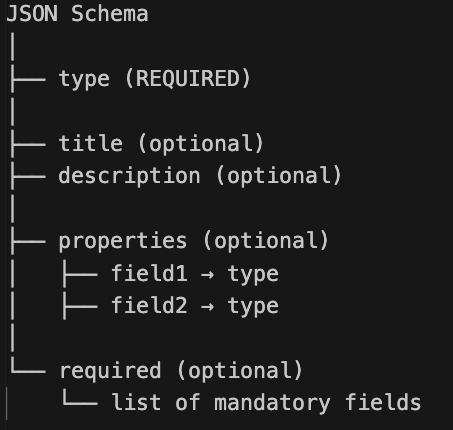

##### Mental model for order for keywords(easy to remember)

- Think like this:
    - What is this? → title, description
    - What kind of data? → type
    - What fields are inside? → properties
    - Which fields are mandatory? → required

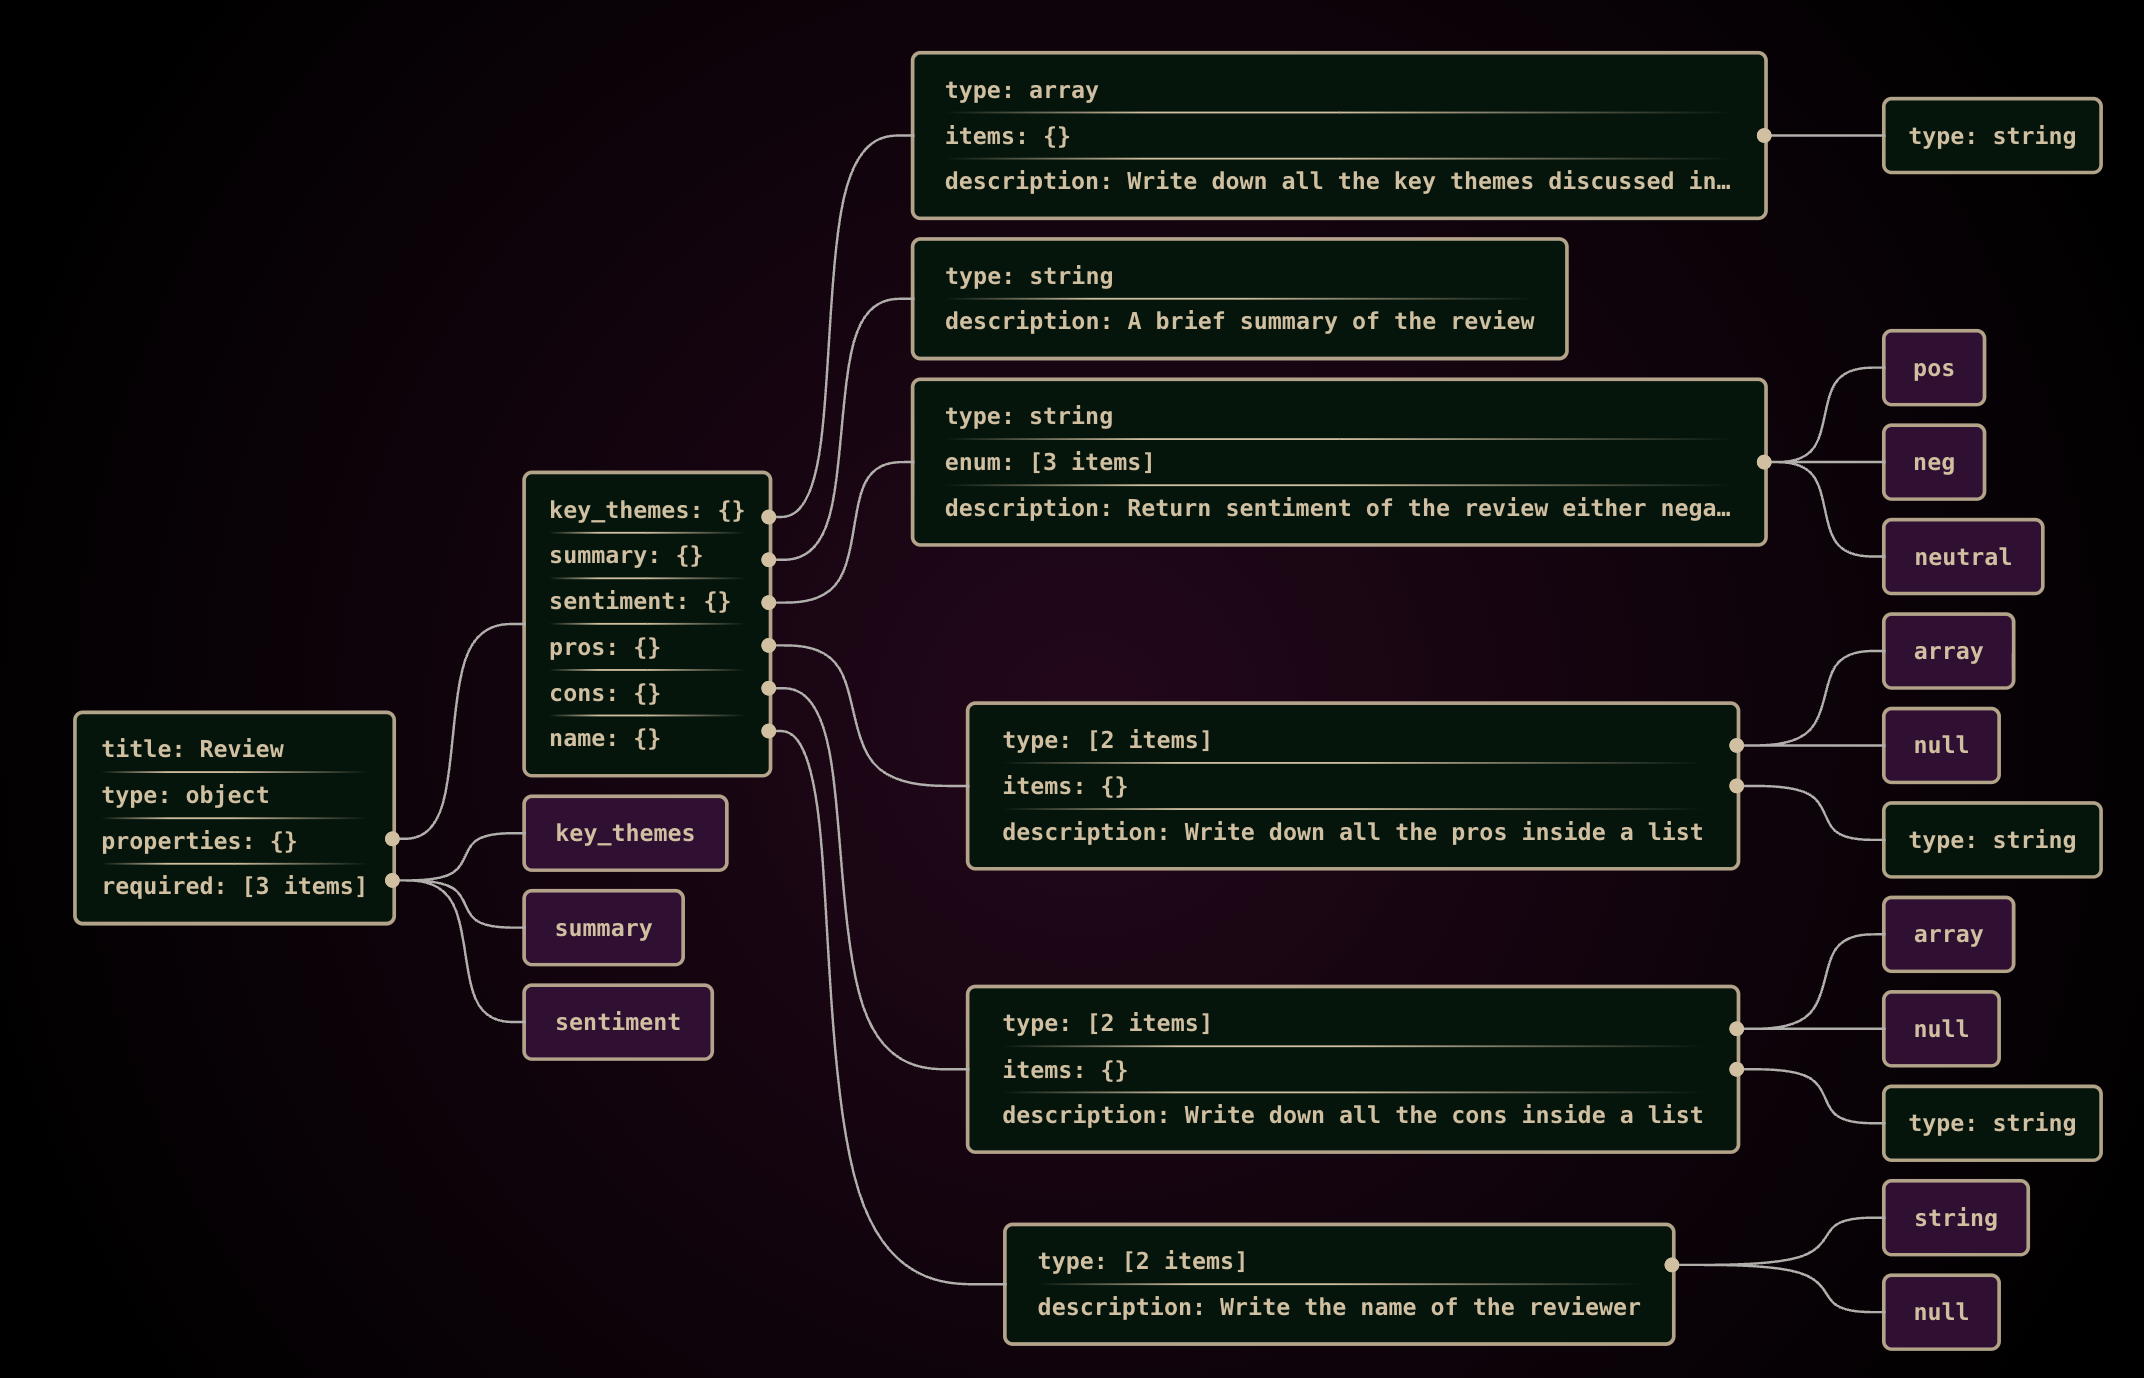

In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

model = ChatOpenAI(model="gpt-5-mini")

# schema
json_schema = {
  "title": "Review",
  "type": "object",
  "properties": {
    "key_themes": {
      "type": "array",
      "items": {
        "type": "string"
      },
      "description": "Write down all the key themes discussed in the review in a list"
    },
    "summary": {
      "type": "string",
      "description": "A brief summary of the review"
    },
    "sentiment": {
      "type": "string",
      "enum": ["pos", "neg"],
      "description": "Return sentiment of the review either negative, positive or neutral"
    },
    "pros": {
      "type": ["array", "null"],
      "items": {
        "type": "string"
      },
      "description": "Write down all the pros inside a list"
    },
    "cons": {
      "type": ["array", "null"],
      "items": {
        "type": "string"
      },
      "description": "Write down all the cons inside a list"
    },
    "name": {
      "type": ["string", "null"],
      "description": "Write the name of the reviewer"
    }
  },
  "required": ["key_themes", "summary", "sentiment"]
}


structured_model = model.with_structured_output(json_schema)

result = structured_model.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful
                                 
Review by Nitish Singh
""")

print(result)
type(result) 

In [ ]:
from pydantic import BaseModel, Field, model_validator
from typing import Optional
from langchain_openai import ChatOpenAI

class Person(BaseModel):
    name: str = Field(description="Person's name")
    age: int = Field(description="Person's age")
    is_adult: Optional[bool] = Field(default=None, description="True if age >= 18")

    @model_validator(mode="after")
    def set_is_adult(self):
        if self.age is not None:
            self.is_adult = self.age >= 18
        return self

llm = ChatOpenAI(
    model="gpt-5-nano",
    temperature=0
)

structured_llm = llm.with_structured_output(
    Person,
    method="json_mode"
)

response = structured_llm.invoke(
    "Extract the information and return the result as JSON. "
    "My name is Rahul and I am 19 years old."
)

print(response)
print(type(response))


In [ ]:
from pydantic import BaseModel, Field, model_validator
from typing import Optional
from langchain_openai import ChatOpenAI

class Person(BaseModel):
    name: str = Field(description="Person's name")
    age: int = Field(description="Person's age")
    is_adult: Optional[bool] = Field(default=None, description="True if age >= 18")

    @model_validator(mode="after")
    def set_is_adult(self):
        if self.age is not None:
            self.is_adult = self.age >= 18
        return self

llm = ChatOpenAI(
    model="gpt-5-nano",
    temperature=0
)

structured_llm = llm.with_structured_output(
    Person,
    method="function_calling"
)

response = structured_llm.invoke(
    "My name is Rahul and I am 19 years old."
)

print(response)
print(type(response))
